# Análisis Final de Resultados

## Introducción

Este notebook presenta un análisis superficial e interpretación de los resultados de vulnerabilidades detectadas por dos herramientas complementarias:

- **CodeQL**: Análisis estático de código (SAST) - identifica vulnerabilidades en el código fuente
- **Grype**: Análisis de componentes de software (SCA) - identifica vulnerabilidades en dependencias

Ambas herramientas detectan **tipos diferentes** de problemas y no son directamente comparables: CodeQL busca bugs de seguridad en nuestro código, mientras que Grype examina si las librerías que usamos tienen vulnerabilidades conocidas.

A continuación, analizaremos cada una por separado con visualizaciones simples y **explicaremos el mapeo de datos** realizado en cada caso para que entiendas de dónde vienen los números.

# Análisis CodeQL: Vulnerabilidades en Código Fuente

## ¿De dónde vienen los datos?

CodeQL ejecuta análisis estático sobre el código fuente y genera resultados en formato **SARIF v2.1.0** (formato estándar de la industria para reportes de análisis de seguridad).

### Mapeo de datos: SARIF -> JSON normalizado

| Dato original (SARIF) | Dato normalizado | Significado |
|---|---|---|
| `level` | `level` | Severidad del problema: `"error"` (crítico), `"warning"` (medio), `"note"` (bajo) |
| `ruleId` | `rule_id` | Identificador de la regla de seguridad violada (ej: `py/sql-injection`) |
| `message.text` | `message` | Descripción legible del problema |
| `location.physicalLocation` | `file` + `region` | Ubicación exacta: archivo y línea/columna afectada |
| `kind`, `properties` | Se preservan | Información adicional para debugging |

### Decisión de diseño

**Se mantiene el `level` exactamente como lo proporciona SARIF**, sin transformación adicional. A diferencia de Grype (que mapea números a categorías), CodeQL ya viene categorizado.

### Visualizaciones esperadas

- Distribución de problemas por severidad (error/warning/note)
- Reglas más comunes encontradas

In [ ]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup de rutas
project_root = Path().cwd().parent.parent
data_results = project_root / "data" / "results"

print(f"📁 Directorio de resultados: {data_results}")
print(f"✓ Proyecto raíz: {project_root}")

📁 Directorio de resultados: /workspaces/ciberseguridad_2026/data/results
✓ Proyecto raíz: /workspaces/ciberseguridad_2026


In [ ]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(data_results.glob("*-codeql.json"))

print(f"\n📂 Buscando archivos CodeQL en: {data_results}")
print(f"✓ Archivos encontrados: {len(codeql_files)}\n")

# Consolidar en un solo DataFrame
data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)
    
    repo_name = archivo.stem.replace('-codeql', '')
    issues = contenido.get('issues', [])
    
    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"📊 Total de problemas cargados: {len(df_codeql)}")
print(f"📋 Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


📂 Buscando archivos CodeQL en: /workspaces/ciberseguridad_2026/data/results
✓ Archivos encontrados: 3

📊 Total de problemas cargados: 238
📋 Repositorios únicos: 3



In [ ]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts().sort_index(ascending=False)
    
    print("📊 Problemas por Nivel de Severidad:")
    print("=" * 50)
    for nivel, cantidad in stats_severity.items():
        emoji = "🔴" if nivel == "error" else "🟡" if nivel == "warning" else "⚪"
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{emoji} {nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")
    
    print(f"\n📈 Total general: {len(df_codeql)} problemas encontrados")
else:
    print("❌ No hay datos de CodeQL disponibles")

📊 Problemas por Nivel de Severidad:
🟡 WARNING: 238 (100.0%)

📈 Total general: 238 problemas encontrados


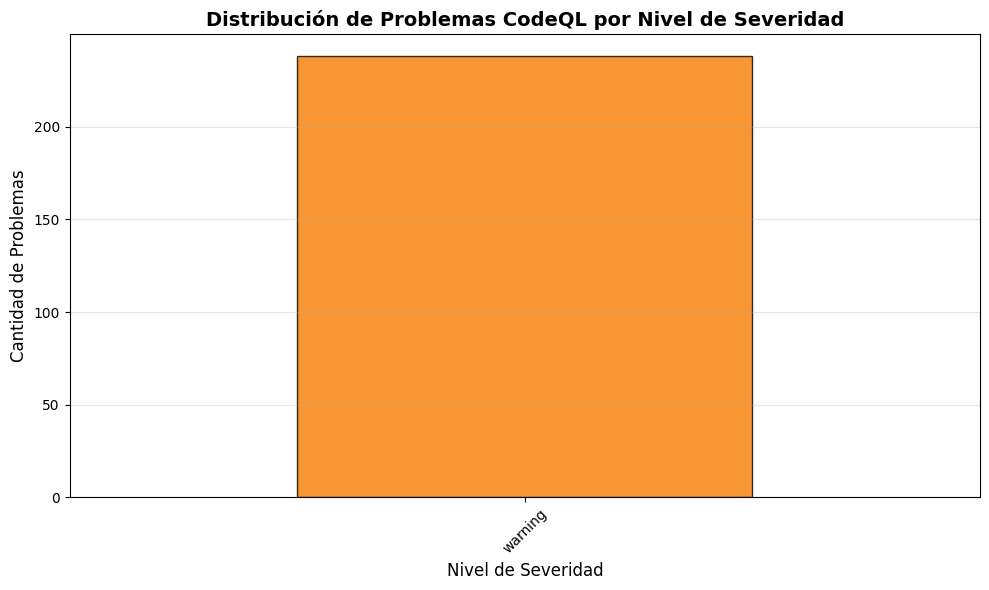

In [ ]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    stats_severity = df_codeql['level'].value_counts().sort_index(ascending=False)
    
    # Colores según severidad
    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575') for nivel in stats_severity.index]
    
    stats_severity.plot(kind='bar', ax=ax, color=color_list, edgecolor='black', alpha=0.8)
    
    ax.set_title('Distribución de Problemas CodeQL por Nivel de Severidad', fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

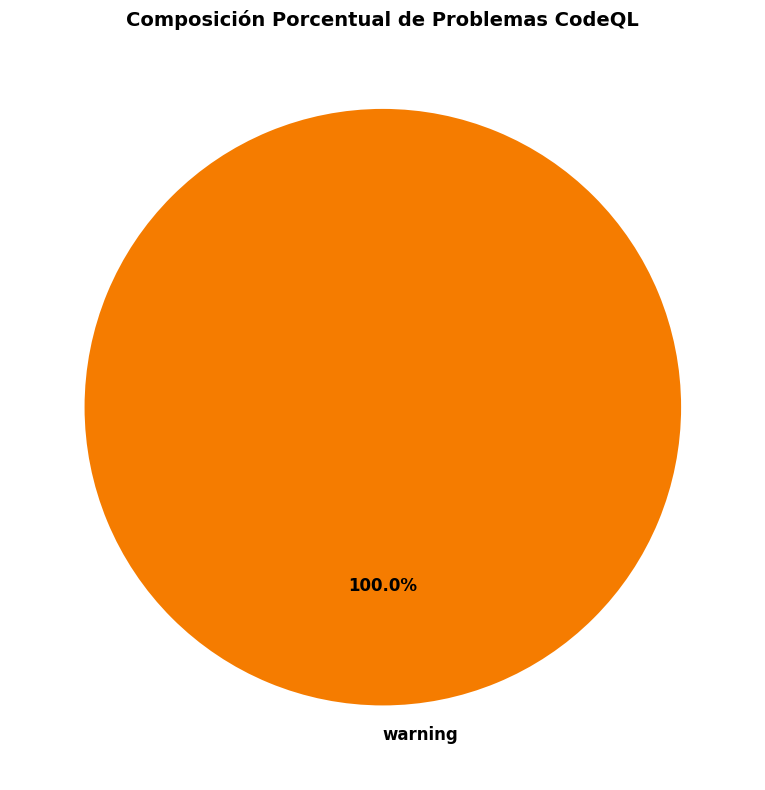

In [ ]:
# Gráfico: Composición por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    stats_severity = df_codeql['level'].value_counts()
    
    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575') for nivel in stats_severity.index]
    
    wedges, texts, autotexts = ax.pie(
        stats_severity.values,
        labels=stats_severity.index,
        autopct='%1.1f%%',
        colors=color_list,
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )
    
    ax.set_title('Composición Porcentual de Problemas CodeQL', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

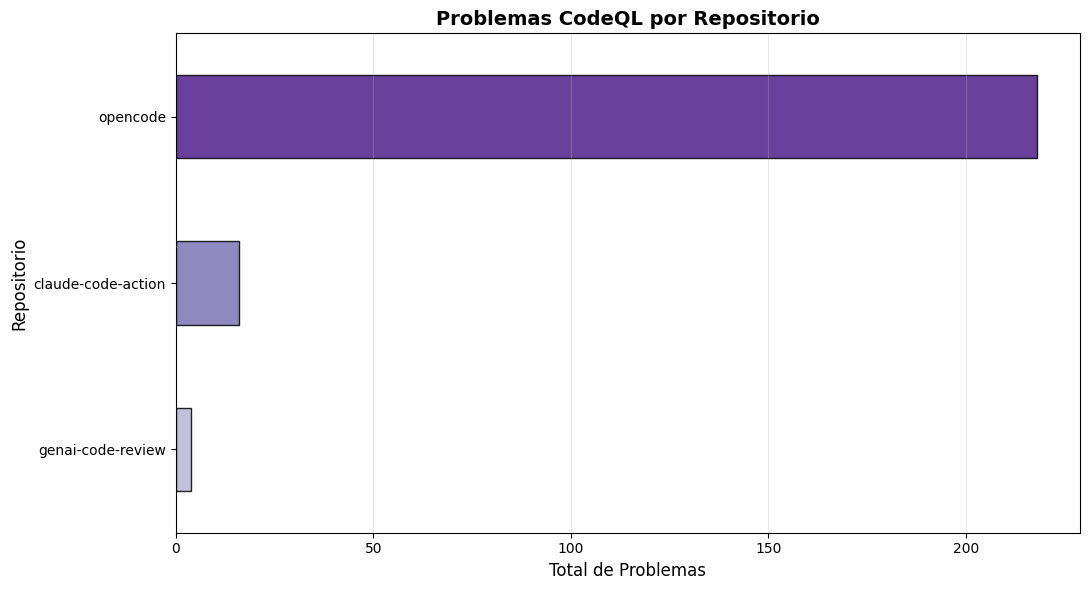

In [ ]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))
    
    issues_por_repo = df_codeql['repo'].value_counts().sort_values(ascending=True)
    
    # Colores del gradiente (más oscuro = más issues)
    colores_gradiente = plt.cm.Purples(np.linspace(0.4, 0.9, len(issues_por_repo)))
    
    issues_por_repo.plot(kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)
    
    ax.set_title('Problemas CodeQL por Repositorio', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

In [ ]:
# Top 5 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(10)
    
    print("\n🎯 Top 10 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
else:
    print("❌ No hay datos disponibles")


🎯 Top 10 Reglas de Seguridad Más Frecuentes:
 1. js/unused-local-variable                 112 ( 47.1%)
 2. js/trivial-conditional                    33 ( 13.9%)
 3. js/property-access-on-non-object          20 (  8.4%)
 4. js/insecure-temporary-file                14 (  5.9%)
 5. js/http-to-file-access                     6 (  2.5%)
 6. js/incomplete-sanitization                 5 (  2.1%)
 7. js/syntax-error                            4 (  1.7%)
 8. js/useless-expression                      4 (  1.7%)
 9. js/useless-assignment-to-local             4 (  1.7%)
10. py/unused-import                           3 (  1.3%)


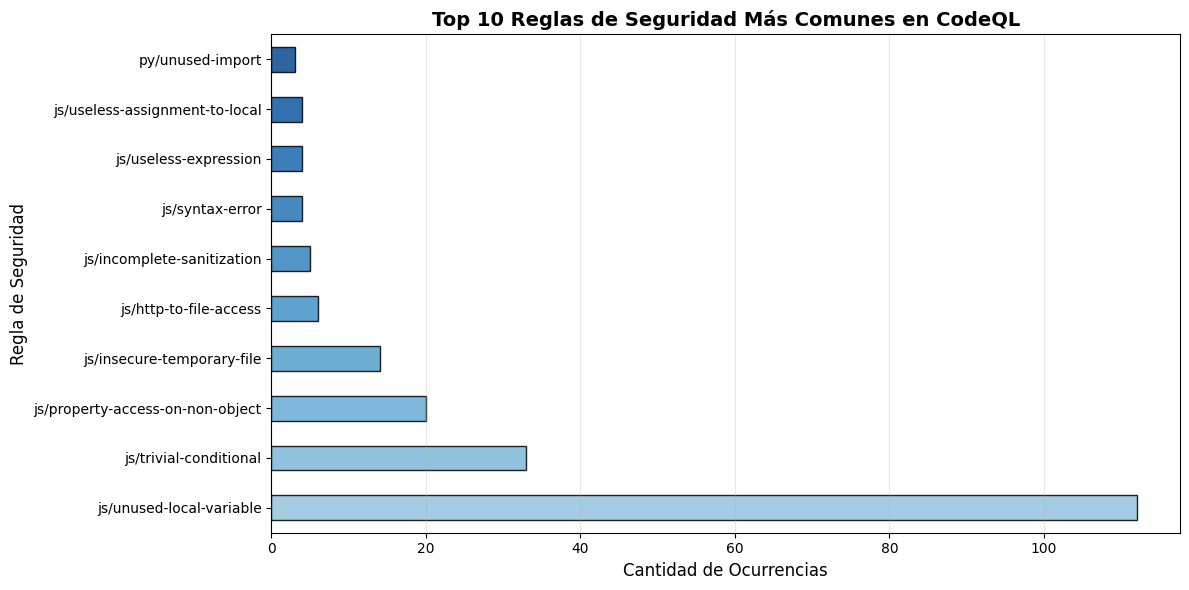

In [ ]:
# Gráfico: Top 10 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    top_rules = df_codeql['rule_id'].value_counts().head(10)
    
    # Colores del gradiente (más oscuro = más frecuente)
    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))
    
    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)
    
    ax.set_title('Top 10 Reglas de Seguridad Más Comunes en CodeQL', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

# Análisis Grype: Vulnerabilidades en Dependencias

## ¿De dónde vienen los datos?

Grype escanea fuentes de dependencias (package.json, requirements.txt, pom.xml, etc.) y las compara contra bases de datos de vulnerabilidades conocidas (CVE, NVD). Devuelve resultados en JSON con información de cada vulnerabilidad encontrada.

### Mapeo de datos: JSON de Grype -> JSON normalizado

| Dato original (Grype) | Dato normalizado | Significado |
|---|---|---|
| `artifact.name` | `package_name` | Nombre de la librería vulnerable (ej: `django`, `lodash`) |
| `artifact.version` | `current_version` | Versión de la librería actualmente instalada |
| `vulnerability.id` | `vuln_id` | Identificador único: CVE-XXXX-XXXXX o equivalente |
| `metadata.cvss[0].score` | `cvss_score` | Puntuación CVSS 0.0-10.0 (escala de severidad numérica) |
| — | `vuln_severity` | **MAPEO**: CVSS→categoría: critical (≥9.0), high (≥7.0), medium (≥4.0), low (<4.0) |
| `fix.versions[0]` | `fix_version` | Versión con el parche disponible (o "N/A" si no hay) |
| `vulnerability.description` | `message` | Descripción del problema |

### Decisión de diseño

**Se realiza transformación CVSS score -> severidad** para mayor legibilidad, pero **se preservan AMBOS valores**. Esto permite:

- Comparar fácilmente con SLAs ("critical en 24h, high en 72h")
- Mantener precisión para usuarios avanzados (CVSS score exacto)

### Visualizaciones esperadas

- Distribución de vulnerabilidades por severidad CVSS
- Paquetes más vulnerables del proyecto

In [ ]:
# Cargar todos los análisis Grype
grype_files = sorted(data_results.glob("*-grype.json"))

print(f"\n📂 Buscando archivos Grype en: {data_results}")
print(f"✓ Archivos encontrados: {len(grype_files)}\n")

# Consolidar en un solo DataFrame
data_grype = []

for archivo in grype_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)
    
    repo_name = archivo.stem.replace('-grype', '')
    vulns = contenido.get('vulnerabilities', [])
    
    for vuln in vulns:
        vuln['repo'] = repo_name
        data_grype.append(vuln)

df_grype = pd.DataFrame(data_grype)

print(f"📊 Total de vulnerabilidades cargadas: {len(df_grype)}")
print(f"📋 Repositorios únicos: {df_grype['repo'].nunique() if len(df_grype) > 0 else 0}\n")


📂 Buscando archivos Grype en: /workspaces/ciberseguridad_2026/data/results
✓ Archivos encontrados: 3

📊 Total de vulnerabilidades cargadas: 17
📋 Repositorios únicos: 3



In [ ]:
# Estadísticas por severidad (con rangos CVSS)
if len(df_grype) > 0:
    stats_severity = df_grype['vuln_severity'].value_counts()
    
    # Mapeo de rangos CVSS
    cvss_ranges = {
        'critical': '9.0 - 10.0',
        'high': '7.0 - 8.9',
        'medium': '4.0 - 6.9',
        'low': '0.0 - 3.9'
    }
    
    print("🔴 Vulnerabilidades por Nivel de Severidad CVSS:")
    print("=" * 60)
    print(f"{'Severidad':<12} {'Cantidad':<10} {'Rango CVSS':<15} {'%':<8}")
    print("=" * 60)
    
    for severidad in ['critical', 'high', 'medium', 'low']:
        cantidad = stats_severity.get(severidad, 0)
        porcentaje = (cantidad / len(df_grype) * 100) if len(df_grype) > 0 else 0
        rango = cvss_ranges.get(severidad, 'N/A')
        emoji = "🔴" if severidad == "critical" else "🟠" if severidad == "high" else "🟡" if severidad == "medium" else "⚪"
        print(f"{emoji} {severidad:<10} {cantidad:<10} {rango:<15} {porcentaje:>6.1f}%")
    
    print("=" * 60)
    print(f"📈 Total general: {len(df_grype)} vulnerabilidades encontradas")
else:
    print("❌ No hay datos de Grype disponibles")

🔴 Vulnerabilidades por Nivel de Severidad CVSS:
Severidad    Cantidad   Rango CVSS      %       
🔴 critical   0          9.0 - 10.0         0.0%
🟠 high       0          7.0 - 8.9          0.0%
🟡 medium     0          4.0 - 6.9          0.0%
⚪ low        17         0.0 - 3.9        100.0%
📈 Total general: 17 vulnerabilidades encontradas


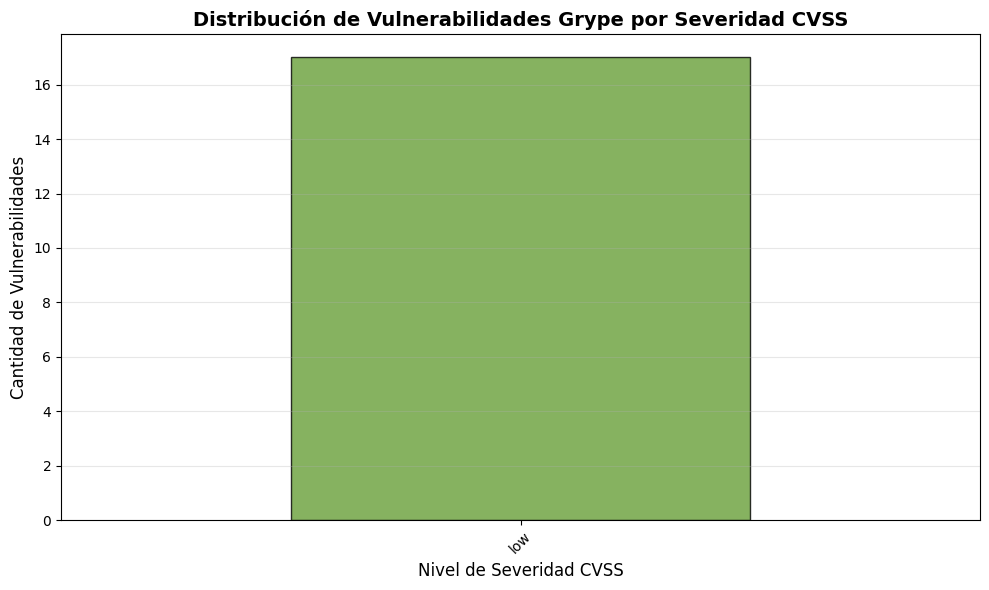

In [ ]:
# Gráfico: Distribución por severidad
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Ordenar correctamente: critical > high > medium > low
    severidad_order = ['critical', 'high', 'medium', 'low']
    stats_severity = df_grype['vuln_severity'].value_counts()
    stats_severity = stats_severity.reindex([s for s in severidad_order if s in stats_severity.index])
    
    # Colores según severidad
    colores = {'critical': '#b71c1c', 'high': '#e64a19', 'medium': '#fbc02d', 'low': '#689f38'}
    color_list = [colores.get(nivel, '#757575') for nivel in stats_severity.index]
    
    stats_severity.plot(kind='bar', ax=ax, color=color_list, edgecolor='black', alpha=0.8)
    
    ax.set_title('Distribución de Vulnerabilidades Grype por Severidad CVSS', fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad CVSS', fontsize=12)
    ax.set_ylabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

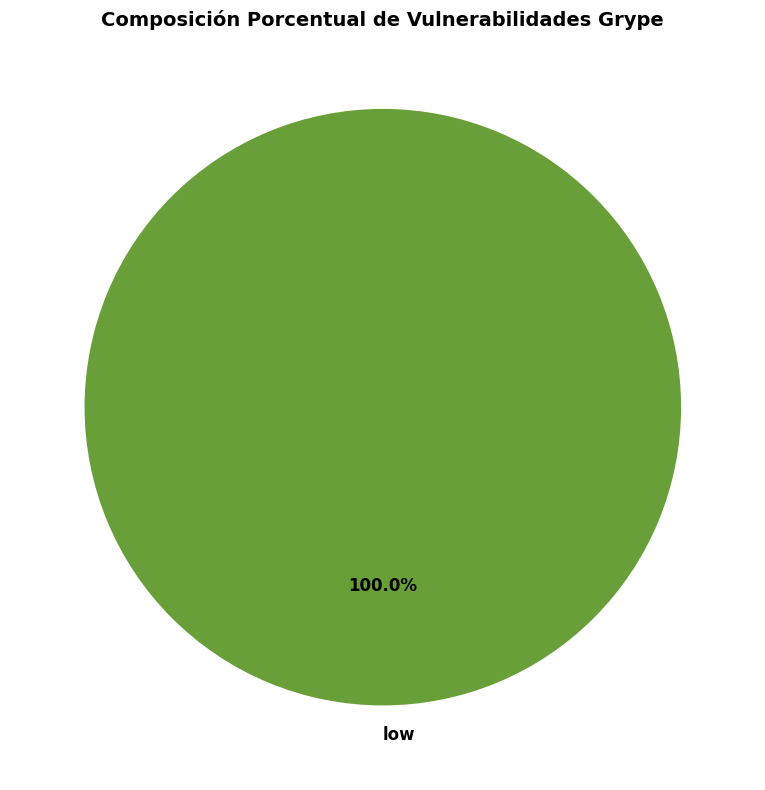

In [ ]:
# Gráfico: Composición por severidad
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Ordenar correctamente
    severidad_order = ['critical', 'high', 'medium', 'low']
    stats_severity = df_grype['vuln_severity'].value_counts()
    stats_severity = stats_severity.reindex([s for s in severidad_order if s in stats_severity.index])
    
    colores = {'critical': '#b71c1c', 'high': '#e64a19', 'medium': '#fbc02d', 'low': '#689f38'}
    color_list = [colores.get(nivel, '#757575') for nivel in stats_severity.index]
    
    wedges, texts, autotexts = ax.pie(
        stats_severity.values,
        labels=stats_severity.index,
        autopct='%1.1f%%',
        colors=color_list,
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )
    
    ax.set_title('Composición Porcentual de Vulnerabilidades Grype', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

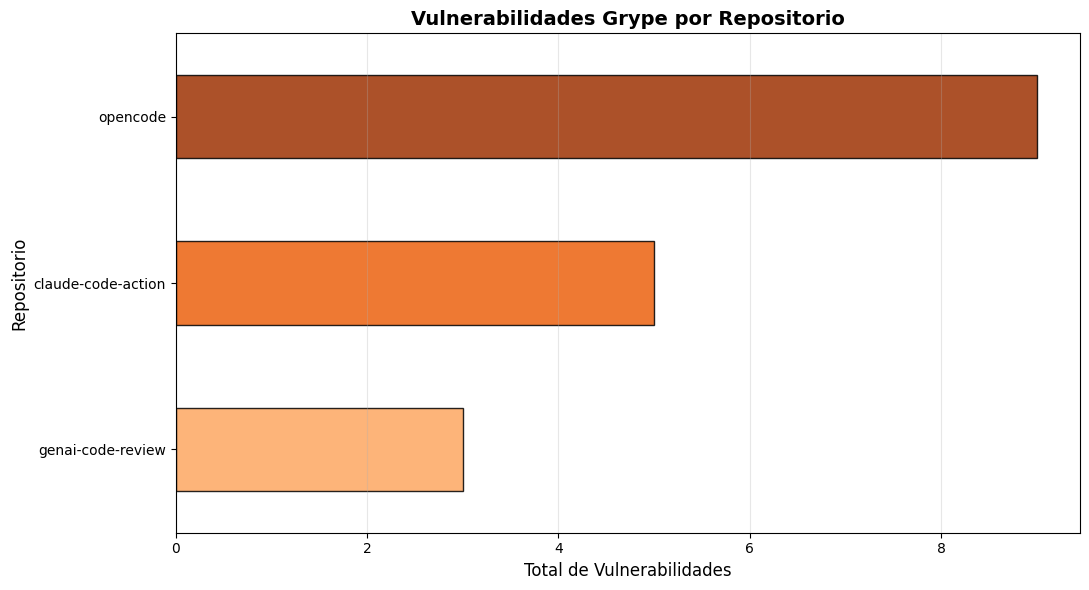

In [ ]:
# Gráfico: Vulnerabilidades por repositorio (Grype)
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))
    
    vulns_por_repo = df_grype['repo'].value_counts().sort_values(ascending=True)
    
    # Colores del gradiente (más oscuro = más vulns)
    colores_gradiente = plt.cm.Oranges(np.linspace(0.4, 0.9, len(vulns_por_repo)))
    
    vulns_por_repo.plot(kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)
    
    ax.set_title('Vulnerabilidades Grype por Repositorio', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Vulnerabilidades', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

In [ ]:
# Top 5 paquetes más vulnerables
if len(df_grype) > 0:
    # Agrupar por paquete y mostrar info relevante
    top_packages = df_grype['package_name'].value_counts().head(10)
    
    print("\n📦 Top 10 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)
    
    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = top_packages[pkg_name]
        version = pkg_data.get('current_version', 'N/A')
        fix = pkg_data.get('fix_version', 'N/A')
        fix_status = "✓ Sí" if fix != 'N/A' else "✗ No"
        
        print(f"{pkg_name:<30} {cantidad:<10} {str(version):<15} {fix_status:<8}")
    
else:
    print("❌ No hay datos disponibles")


📦 Top 10 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
undici                         5          5.29.0          ✗ No    
requests                       3          2.31.0          ✗ No    
tar                            2          0.4.44          ✗ No    
actions/download-artifact      2          v4              ✗ No    
quinn-proto                    1          0.11.13         ✗ No    
bytes                          1          1.11.0          ✗ No    
time                           1          0.3.44          ✗ No    
glib                           1          0.18.5          ✗ No    
rustls-webpki                  1          0.103.8         ✗ No    


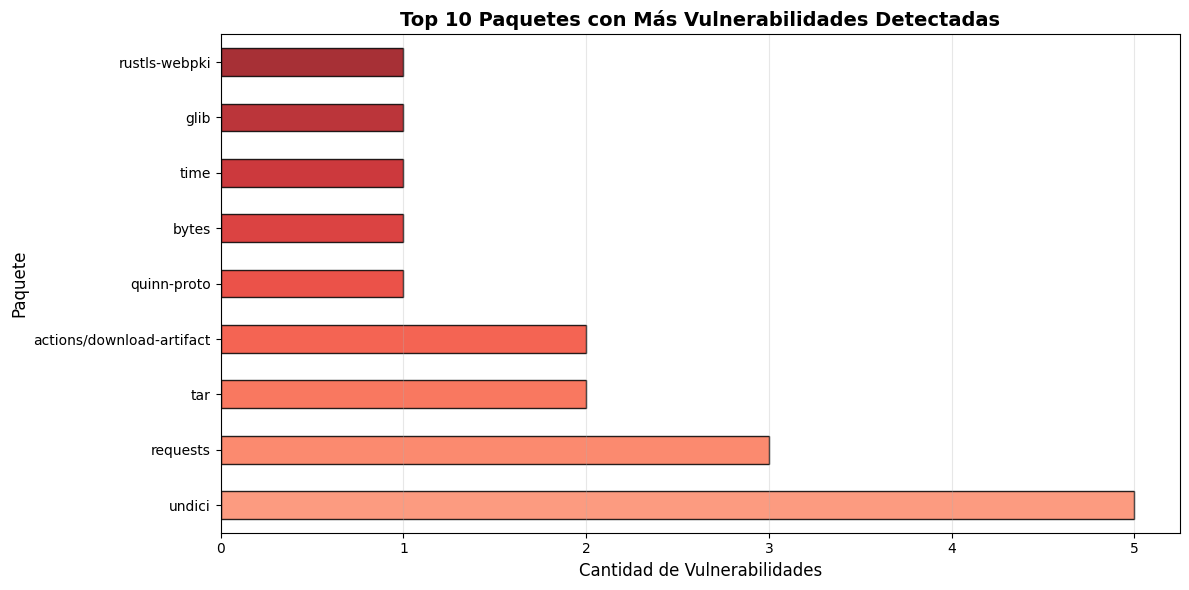

In [ ]:
# Gráfico: Top 10 paquetes con más vulnerabilidades
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    top_packages = df_grype['package_name'].value_counts().head(10)
    
    # Colores del gradiente (más oscuro = más vulns)
    colores_gradiente = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_packages)))
    
    top_packages.plot(kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)
    
    ax.set_title('Top 10 Paquetes con Más Vulnerabilidades Detectadas', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_ylabel('Paquete', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

## Conclusiones

### Dos perspectivas complementarias

Como habrás observado, **CodeQL y Grype detectan problemas completamente diferentes**:

| Aspecto | CodeQL (SAST) | Grype (SCA) |
|--------|---|---|
| **¿Qué analiza?** | Nuestro propio código fuente | Las librerías que usamos |
| **Severidad** | `error`, `warning`, `note` | CVSS score -> critical, high, medium, low |
| **Acción típica** | Refactorizar código, revisar patrones | Actualizar versión de librería |
| **Remediación** | Manual (requiere fix de código) | Automática (cambiar versión) |

### Cómo interpretarlos

- **CodeQL errors**: Son críticos y pueden permitir ataques. Requieren revisión y fix de código
- **Grype critical**: Vulnerabilidades públicamente conocidas. Actualizar la librería es urgente
- **Ambas**: Son parte de una estrategia integral de seguridad. Usa ambas para máxima cobertura

### Próximos pasos

1. **Para CodeQL errors**: Revisa el análisis detallado en `generacion_codeql.ipynb`
2. **Para Grype critical**: Revisa el análisis detallado en `generacion_grype.ipynb`
3. **Para SBOMs**: Consulta `generacion_sbom.ipynb` para inventario de dependencias